In [22]:
import pyxdf 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [3]:
file_path=r"C:\Users\abolhassni\Desktop\TU Darmstadt\Term3\ANSYMB\LSL\imu_motion_capture_analysis\data\raw\TEST 27 MAI\squat.xdf"

streams, header=pyxdf.load_xdf(file_path)

In [5]:
print(len(streams))
print(len(header))

4
1


In [6]:
names=[]
for i in enumerate(streams):
    sensor_name=streams[0]["info"]["name"]
    names.append(sensor_name)


names

[['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5']]

In [7]:
sensor_dfs = {}

for stream in streams:
    sensor_name = stream["info"]["name"][0]
    
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    time_insert = time - time[0]
    
    channels = stream["info"]["desc"][0]["channels"][0]["channel"]
    column_names = [ch["label"][0] for ch in channels]
    
    df = pd.DataFrame(data, columns=column_names)
    
    df.insert(0, "time_stamp", time)
    df.insert(1, "time_insert", time_insert)
    
    sensor_dfs[sensor_name] = df

In [8]:
sensor_dfs['Xsens_MTw2_00B4D0C8']

,time_stamp,time_insert,qw,qx,qy,qz,ax,ay,az,gx,gy,gz,mx,my,mz,packet_counter,sample_time_fine
0,517041.743456,0.000000,0.726287,-0.220196,0.564693,0.324256,-9.597530,1.009320,1.108889,-0.266609,-1.325527,0.091712,0.734375,-0.370850,0.062500,48932.0,0.0
1,517041.753530,0.010074,0.729586,-0.218559,0.559688,0.326627,-9.536712,1.004090,1.353372,-0.208898,-1.309303,0.092381,0.736816,-0.368652,0.054443,48933.0,0.0
2,517041.763604,0.020147,0.733093,-0.216401,0.554879,0.328411,-9.456758,0.858895,1.838931,-0.045748,-1.311154,0.059185,0.734619,-0.370361,0.038818,48934.0,0.0
3,517041.773678,0.030221,0.736672,-0.213876,0.550220,0.329892,-9.300513,0.438964,2.672510,0.055172,-1.309351,0.058055,0.728516,-0.372314,0.033691,48935.0,0.0
4,517041.783751,0.040295,0.740222,-0.211386,0.545489,0.331404,-9.261868,0.325740,3.199606,0.040086,-1.314662,0.056740,0.725342,-0.359863,0.029541,48936.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,517061.729702,19.986246,0.550609,-0.315407,0.720146,0.280604,-9.537122,0.577985,-2.315415,-0.003852,-0.012063,-0.009971,0.714600,-0.384766,0.435059,50931.0,0.0
1985,517061.739776,19.996320,0.550654,-0.315419,0.720100,0.280620,-9.554953,0.549474,-2.340990,-0.002915,-0.010933,-0.008032,0.718506,-0.375244,0.445801,50932.0,0.0
1986,517061.749850,20.006393,0.550705,-0.315449,0.720041,0.280637,-9.549017,0.525132,-2.341899,-0.007211,-0.011337,-0.011749,0.717041,-0.380859,0.436035,50933.0,0.0
1987,517061.759923,20.016467,0.550752,-0.315486,0.719988,0.280639,-9.543077,0.500534,-2.342864,-0.004144,-0.009765,-0.013722,0.722412,-0.381348,0.444580,50934.0,0.0


In [13]:
SENSOR_NAME_MAP = {
    "Xsens_MTw2_00B4D0C5": "Pelv",
    "Xsens_MTw2_00B4D0BE": "lLeg_L",
    "Xsens_MTw2_00B4D0C8": "uLeg_L",
    "Xsens_MTw2_00B4D0D0": "Foot_L",
}

In [14]:
sensor_dfs_mapped = {}

for old_name, df in sensor_dfs.items():
    new_name = SENSOR_NAME_MAP.get(old_name, old_name)
    sensor_dfs_mapped[new_name] = df

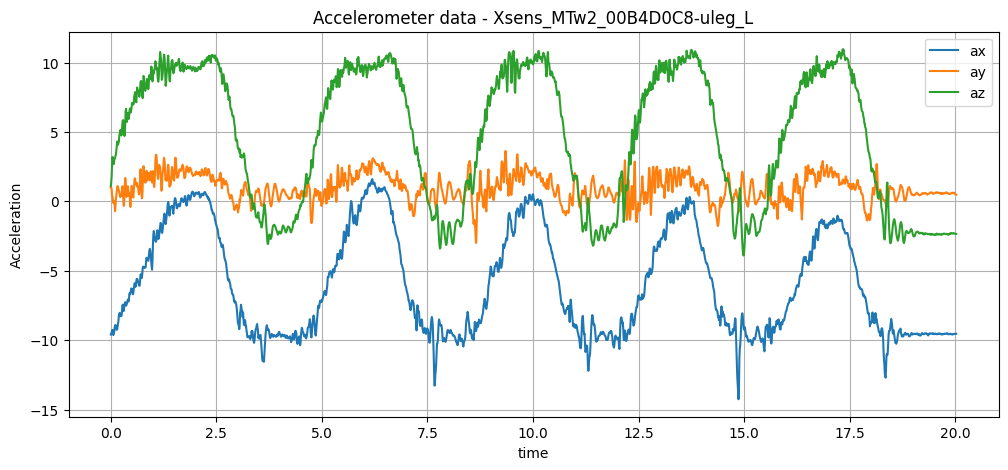

In [16]:
df = sensor_dfs_mapped["uLeg_L"]
    
t = df["time_insert"]
    
plt.figure(figsize=(12, 5))

plt.plot(t, df["ax"], label="ax")
plt.plot(t, df["ay"], label="ay")
plt.plot(t, df["az"], label="az")

plt.xlabel("time")
plt.ylabel("Acceleration")
plt.title("Accelerometer data - Xsens_MTw2_00B4D0C8-uleg_L")
plt.legend()
plt.grid(True)
plt.show()

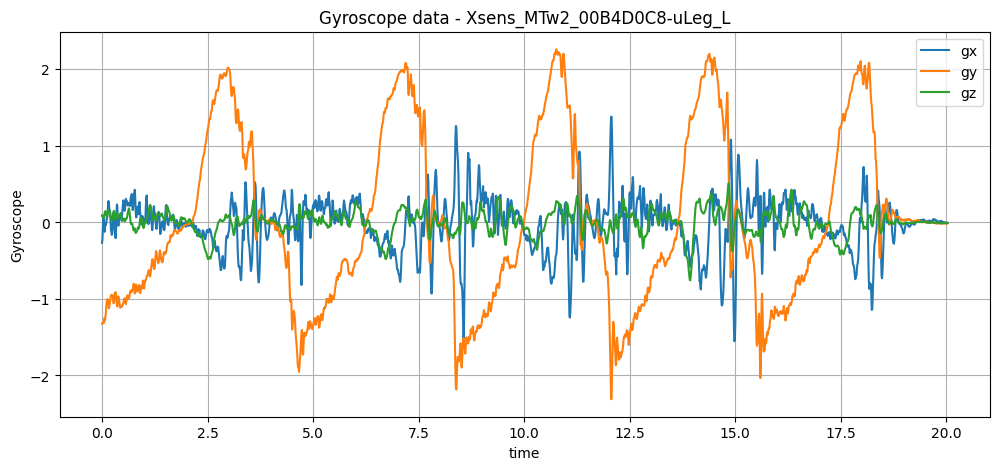

In [18]:
df = sensor_dfs_mapped["uLeg_L"]
    
t = df["time_insert"]
    
plt.figure(figsize=(12, 5))

plt.plot(t, df["gx"], label="gx")
plt.plot(t, df["gy"], label="gy")
plt.plot(t, df["gz"], label="gz")

plt.xlabel("time")
plt.ylabel("Gyroscope")
plt.title("Gyroscope data - Xsens_MTw2_00B4D0C8-uLeg_L")
plt.legend()
plt.grid(True)
plt.show()

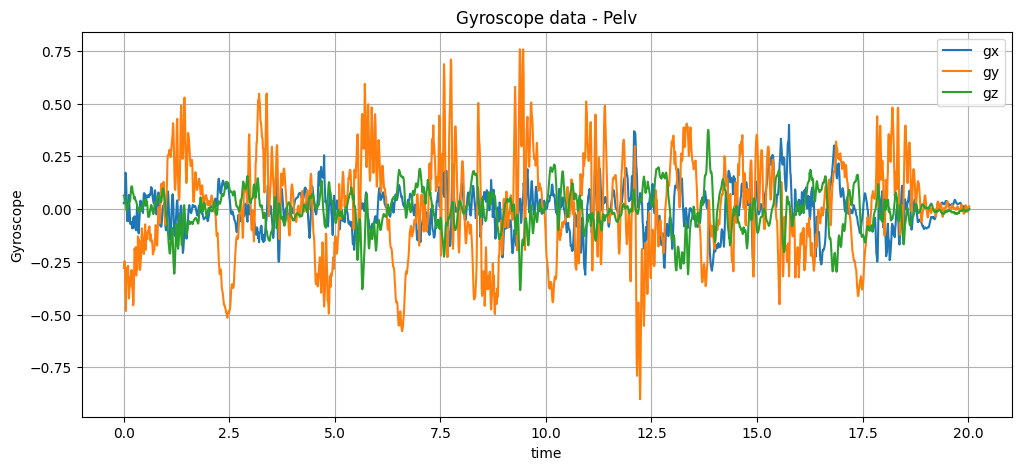

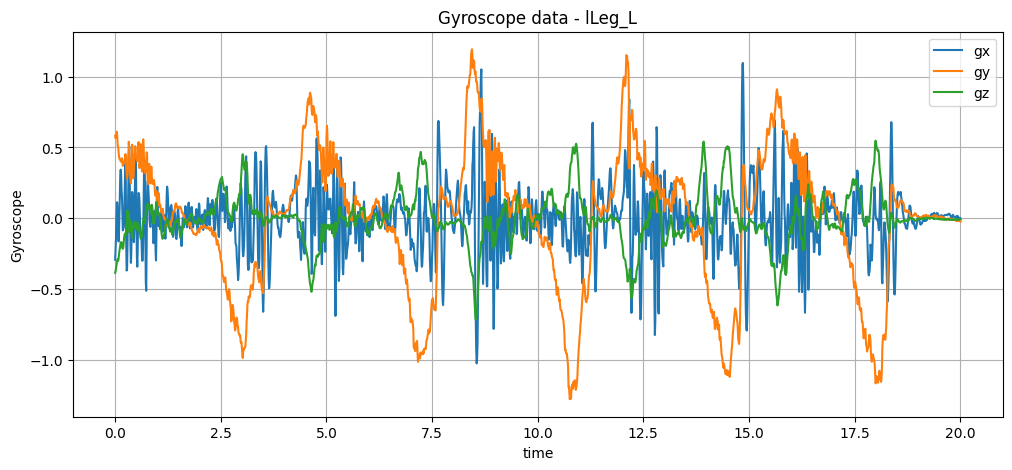

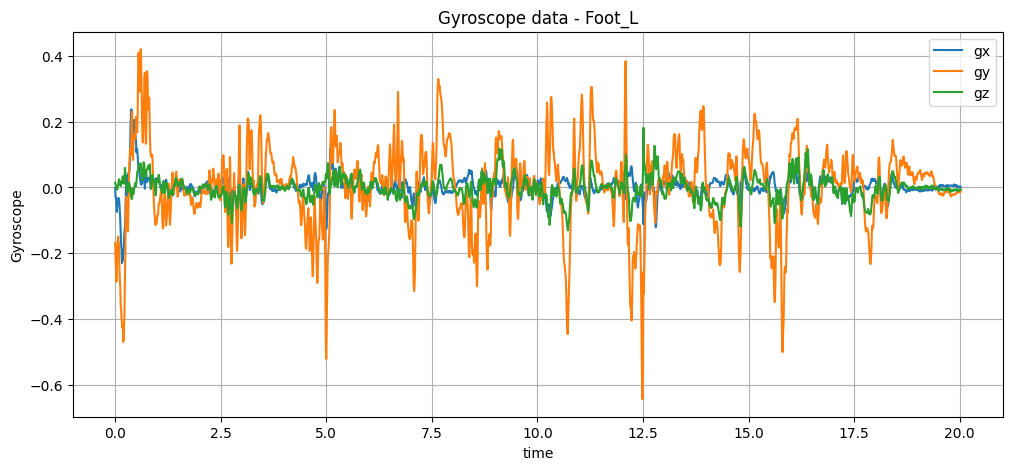

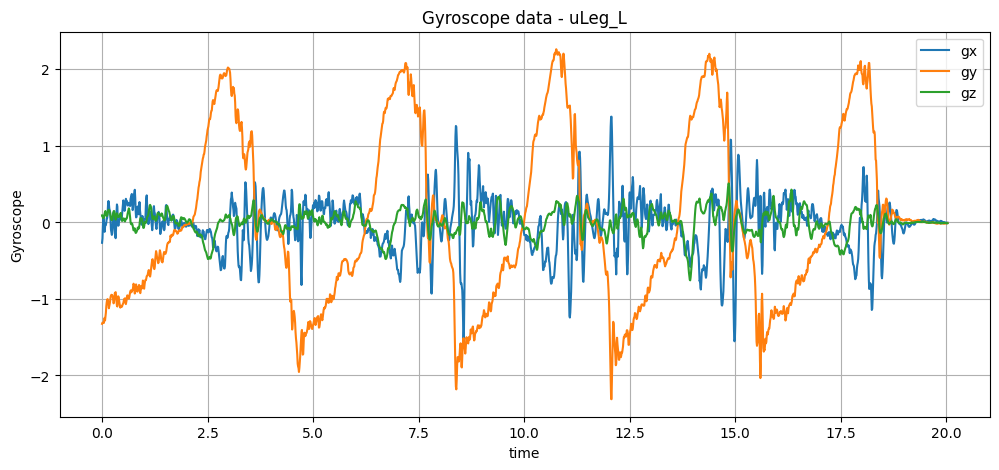

In [19]:
for sensor_name, df in sensor_dfs_mapped.items():
    
    t = df["time_insert"]
    
    plt.figure(figsize=(12, 5))

    plt.plot(t, df["gx"], label="gx")
    plt.plot(t, df["gy"], label="gy")
    plt.plot(t, df["gz"], label="gz")

    plt.xlabel("time")
    plt.ylabel("Gyroscope")
    plt.title(f"Gyroscope data - {sensor_name}")

    plt.legend()
    plt.grid(True)
    plt.show()

* Pelv    → functional axis ≈ -Y
* lLeg_L  → functional axis ≈ -Y
* uLeg_L  → functional axis ≈ -Y
* Foot_L  → functional axis ≈ -Y

1. Für jeden Sensor wurden die drei Gyroskopkomponenten gx, gy und gz aus den Squat-Daten verwendet. 
2. Zunächst wurde der Mittelwert jeder Komponente entfernt, um mögliche Offsets des Gyroskops zu reduzieren. 
3. Anschließend wurde eine Principal Component Analysis (PCA) durchgeführt.
4. Die erste Hauptkomponente beschreibt die Richtung mit der größten Varianz in den Gyroskopdaten und wurde daher als funktionelle Hauptbewegungsachse interpretiert.
5. Zusätzlich wurde die erklärte Varianz berechnet, um zu bewerten, wie deutlich diese Hauptbewegungsachse ausgeprägt ist.

In [23]:



functional_axis = {}

for sensor_name, df in sensor_dfs_mapped.items():
    gyro = df[["gx", "gy", "gz"]].dropna().values
    gyro = gyro - np.mean(gyro, axis=0)

    pca = PCA(n_components=3)
    pca.fit(gyro)

    axis = pca.components_[0]
    axis = axis / np.linalg.norm(axis)

    explained = pca.explained_variance_ratio_[0] * 100

    functional_axis[sensor_name] = axis

    print(sensor_name)
    print("functional axis:", axis)
    print("explained variance:", round(explained, 2), "%")
    print()

Pelv
functional axis: [ 0.03856518 -0.97512156  0.21829057]
explained variance: 78.49 %

lLeg_L
functional axis: [-0.09573045 -0.9544616   0.28255782]
explained variance: 79.83 %

Foot_L
functional axis: [-0.07771182 -0.9857768  -0.14901362]
explained variance: 89.82 %

uLeg_L
functional axis: [ 0.15380487 -0.98806274  0.00871987]
explained variance: 91.56 %

